In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import HTML

In [3]:
# Load dataset
df = pd.read_csv('characterization_dataset.csv')

# Preview (optional)
print("First 5 rows:")
display(df.head())

# Convert full dataset to HTML
html_table = df.to_html(index=False, justify='center')

First 5 rows:


,EmployeeID,Name,Age,Department,Salary,JoinDate,Performance,City
0,101,Amit,25.0,HR,40000.0,2021-05-10,Good,Ahmedabad
1,102,Neha,30.0,IT,60000.0,2020-03-15,Excellent,Mumbai
2,103,Raj,NaN,Finance,55000.0,2019-07-20,Average,Delhi
3,104,Priya,28.0,hr,42000.0,2022-01-12,NaN,Ahmedabad
4,105,Karan,35.0,IT Dept,80000.0,2018-09-30,Excellent,Bangalore


In [4]:
# -------------------------------
# Column Types (dtypes)
# -------------------------------
dtypes_df = df.dtypes.reset_index()
dtypes_df.columns = ['Column Name', 'Data Type']

display(HTML("<h3>Column Data Types</h3>" + dtypes_df.to_html(index=False)))

# -------------------------------
# Descriptive Statistics
# -------------------------------
desc_df = df.describe(include='all').transpose()

display(HTML("<h3>Descriptive Statistics</h3>" + desc_df.to_html()))

Column Name,Data Type
EmployeeID,int64
Name,str
Age,float64
Department,str
Salary,float64
JoinDate,str
Performance,str
City,str


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
EmployeeID,20.0,NaN,NaN,NaN,110.5,5.91608,101.0,105.75,110.5,115.25,120.0
Name,20,20,Amit,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,18.0,NaN,NaN,NaN,31.277778,5.421152,25.0,27.25,29.5,33.75,45.0
Department,19,6,Finance,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Salary,19.0,NaN,NaN,NaN,111789.473684,217313.286127,39000.0,42500.0,55000.0,61500.0,1000000.0
JoinDate,19,19,2021-05-10,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Performance,18,3,Good,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,20,5,Ahmedabad,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
# -------------------------------
# 1. Missing Percentage (HTML)
# -------------------------------
missing_percentage = df.isnull().mean() * 100

missing_df = missing_percentage.reset_index()
missing_df.columns = ['Column Name', 'Missing %']

display(HTML("<h3>Missing Percentage per Column</h3>" + missing_df.to_html(index=False)))

# -------------------------------
# 2. Unique Values (HTML)
# -------------------------------
unique_data = []

# Fix warning → use 'object' + 'string'
for col in df.select_dtypes(include=['object', 'string']):
    unique_vals = df[col].unique()
    unique_data.append([col, ', '.join(map(str, unique_vals))])

unique_df = pd.DataFrame(unique_data, columns=['Column Name', 'Unique Values'])

display(HTML("<h3>Unique Values in Categorical Columns</h3>" + unique_df.to_html(index=False)))

Column Name,Missing %
EmployeeID,0.0
Name,0.0
Age,10.0
Department,5.0
Salary,5.0
JoinDate,5.0
Performance,10.0
City,0.0


Column Name,Unique Values
Name,"Amit, Neha, Raj, Priya, Karan, Simran, Rohit, Sneha, Vikas, Anjali, Deepak, Pooja, Arjun, Meena, Suresh, Kavita, Nikhil, Rina, Alok, Tina"
Department,"HR, IT, Finance, hr, IT Dept, Management, nan"
JoinDate,"2021-05-10, 2020-03-15, 2019-07-20, 2022-01-12, 2018-09-30, 2021-11-05, 2015-06-25, 2020-08-19, 2019-12-01, 2022-04-18, 2018-10-10, 2021-02-14, 2016-07-07, 2022-06-01, 2017-03-22, 2021-09-09, 2019-05-05, nan, 2020-11-11, 2023-01-01"
Performance,"Good, Excellent, Average, nan"
City,"Ahmedabad, Mumbai, Delhi, Bangalore, Pune"


In [9]:
# Example: Combine multiple CSV files
df1 = pd.read_csv('data1.csv')
df2 = pd.read_csv('data2.csv')
# Combine vertically
df_combined = pd.concat([df1, df2], ignore_index=True)
# Combine horizontally (on key)
df_merged = pd.merge(df1, df2, on='EmployeeID', how='inner')

# ✅ show in HTML table
display(HTML("<h3>Merged Dataset</h3>" + df_merged.to_html(index=False)))

EmployeeID,Name,Age,Department,Salary,City,Performance
101,Amit,25.0,HR,40000,Ahmedabad,Good
102,Neha,30.0,IT,60000,Mumbai,Excellent
103,Raj,NaN,Finance,55000,Delhi,Average
104,Priya,28.0,hr,42000,Ahmedabad,NaN
105,Karan,35.0,IT Dept,80000,Bangalore,Excellent
106,Simran,27.0,Finance,52000,Delhi,Good
107,Rohit,45.0,Management,150000,Mumbai,Excellent
108,Sneha,29.0,NaN,48000,Ahmedabad,Average
109,Vikas,31.0,IT,62000,Pune,Good
110,Anjali,26.0,HR,41000,Delhi,Good


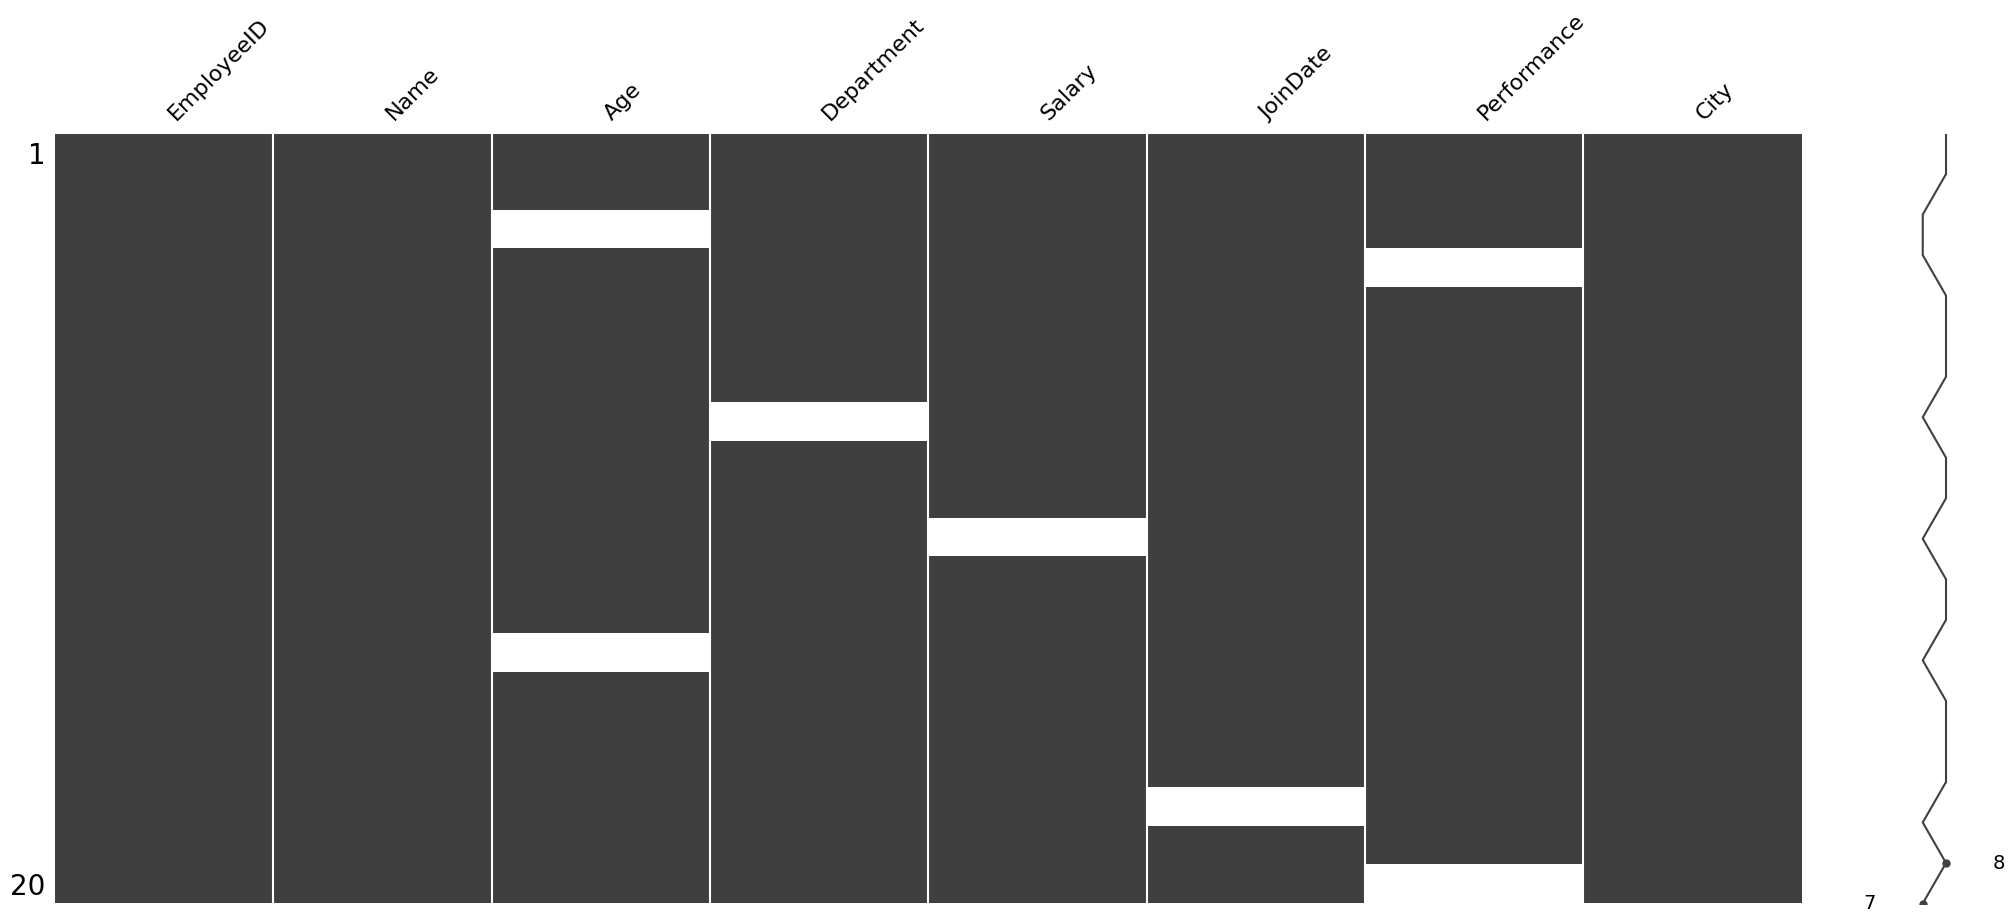

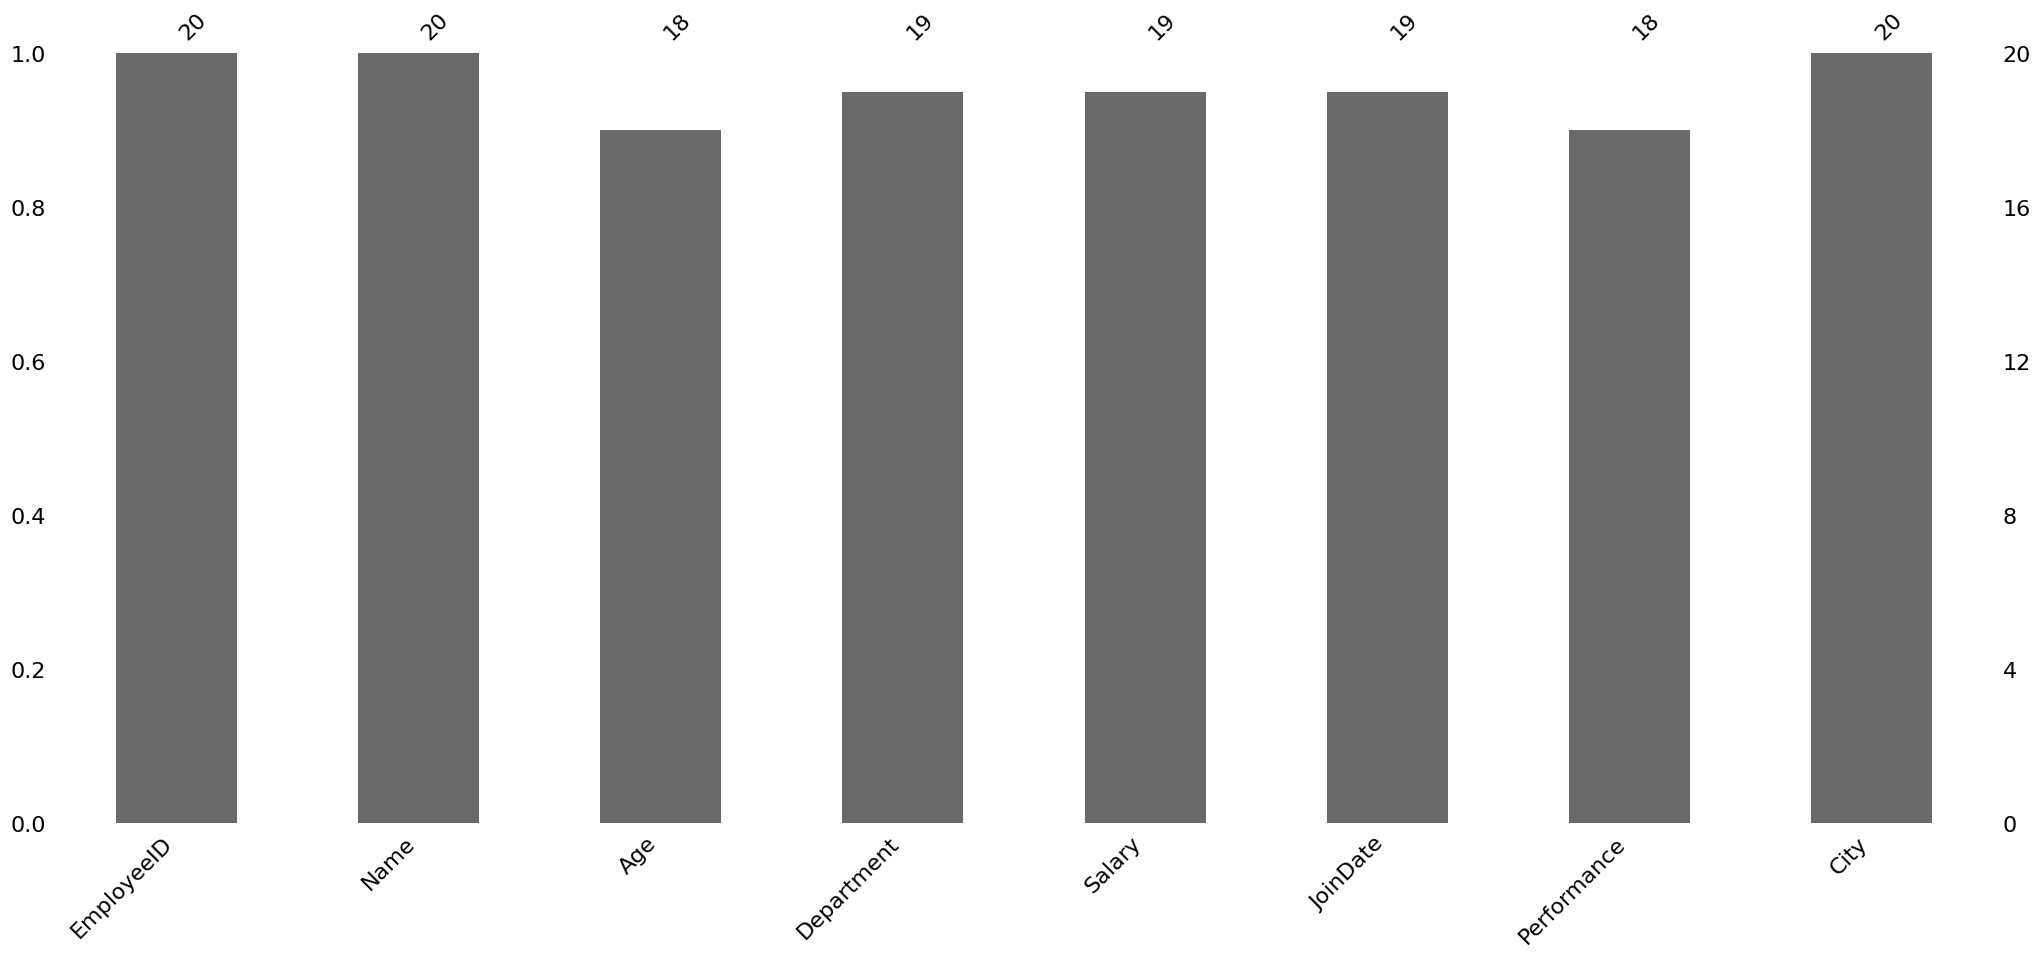

In [10]:
import missingno as msno
# Matrix plot
msno.matrix(df)
plt.show()
# Bar chart
msno.bar(df)
plt.show()

In [11]:
# Categorical column distribution
for col in df.select_dtypes(include=['object', 'string']):
    print(f"\n{col} distribution:\n")
    print(df[col].value_counts(normalize=True) * 100)




Name distribution:

Name
Amit      5.0
Neha      5.0
Raj       5.0
Priya     5.0
Karan     5.0
Simran    5.0
Rohit     5.0
Sneha     5.0
Vikas     5.0
Anjali    5.0
Deepak    5.0
Pooja     5.0
Arjun     5.0
Meena     5.0
Suresh    5.0
Kavita    5.0
Nikhil    5.0
Rina      5.0
Alok      5.0
Tina      5.0
Name: proportion, dtype: float64

Department distribution:

Department
Finance       26.315789
HR            21.052632
IT            15.789474
IT Dept       15.789474
hr            10.526316
Management    10.526316
Name: proportion, dtype: float64

JoinDate distribution:

JoinDate
2021-05-10    5.263158
2020-03-15    5.263158
2019-07-20    5.263158
2022-01-12    5.263158
2018-09-30    5.263158
2021-11-05    5.263158
2015-06-25    5.263158
2020-08-19    5.263158
2019-12-01    5.263158
2022-04-18    5.263158
2018-10-10    5.263158
2021-02-14    5.263158
2016-07-07    5.263158
2022-06-01    5.263158
2017-03-22    5.263158
2021-09-09    5.263158
2019-05-05    5.263158
2020-11-11    5.26315


Correlation Matrix:
             EmployeeID       Age    Salary
EmployeeID    1.000000  0.048375  0.248828
Age           0.048375  1.000000  0.254247
Salary        0.248828  0.254247  1.000000


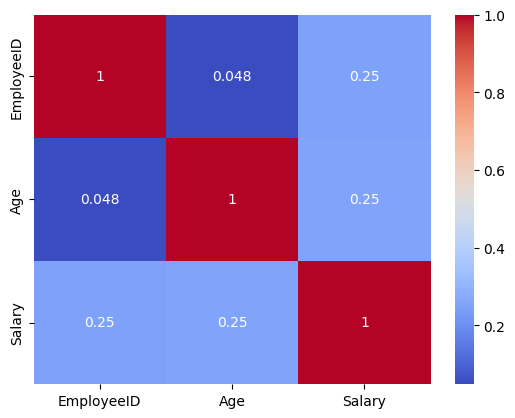

In [12]:
# Correlation matrix (fixed)
corr_matrix = df.corr(numeric_only=True)

print("\nCorrelation Matrix:\n", corr_matrix)

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()